# Convolution and Deconvolution

**Student Name:**  Andrés Jauch
**Country:**  Switzerland
**Semester term:** FS26


## Data & Domain

### Use Case
*Focus: domain and application context*

In the context of the Swiss national energy grid, grid operators monitor high-frequency electrical load telemetry from nationwide smart meters. To make long-term capacity planning decisions, it is often necessary to smooth out volatile intraday spikes (Convolution) to extract the underlying baseload trend. Conversely, if a sensor artificially smooths or blurs a signal due to internal hardware latency, mathematical Deconvolution is required to reconstruct the true, sharp peak demand spikes that originally occurred.

### Problem Statement
*Focus: technical vulnerability*

High-frequency noise and daily volatility obscure macroeconomic demand trends, while sensor latency (acting as an unintended low-pass filter) hides sudden, critical demand spikes. Dispatchers need mathematical tools to deliberately smooth signals for trend analysis, and inversely, to computationally recover lost sharp peaks from degraded sensor data to prevent capacity under-provisioning.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

The objective is to mathematically manipulate the signal's frequency content in the time domain. First, apply Convolution using a moving average filter to smooth the 15-minute load signal and extract the clean daily macro-trend. Second, apply Deconvolution (inverse filtering) to a synthetically blurred signal to prove that obscured high-frequency peaks can be mathematically restored from a degraded measurement.

### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

The selected signal represents total energy consumption measured using grid sensors, expressed in GWh. Its relevant characteristics include distinct daily spikes and macro-level baseload shifts. The data originate from Swissgrid's public "Energie Übersicht CH" dataset (2026 release), providing a high-resolution, continuous 15-minute load curve perfectly suited for mathematical filtering operations.

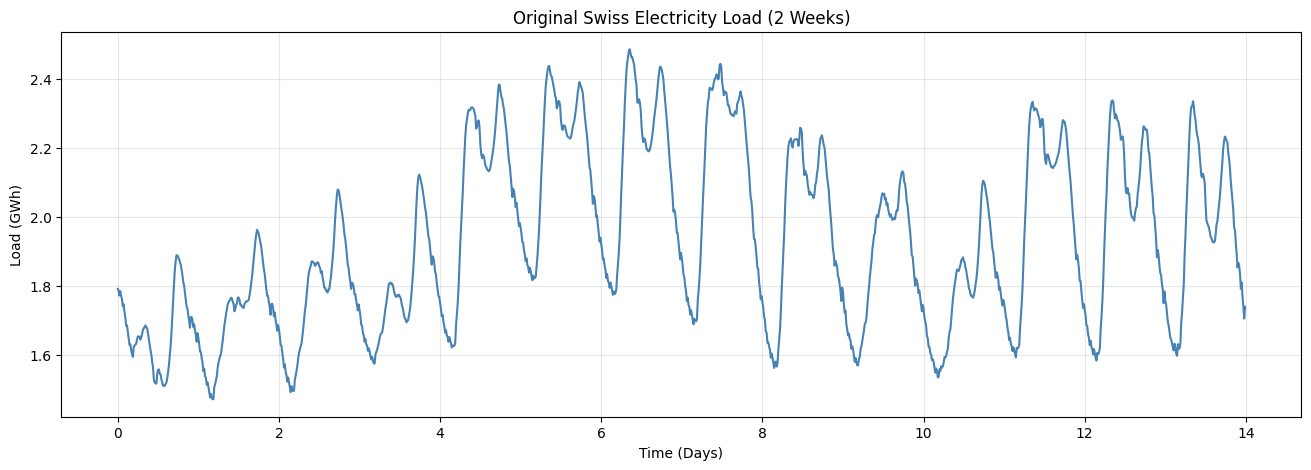

In [2]:
# DATA PREP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal

# Load raw df
raw_df = pd.read_excel('data/EnergieUebersichtCH-2026.xlsx', sheet_name="Zeitreihen0h15", header=None)
signal = raw_df.iloc[3:, 1].astype(float).reset_index(drop=True)

# Select a 2-week window (96 samples/day * 14 days = 1344 samples) for clearer visualization
time_window = 1344
signal_2w = signal[:time_window].values / 1000000 # Convert to GWh

plt.figure(figsize=(16, 5))
plt.plot(np.arange(time_window) / 96, signal_2w, color='steelblue')
plt.title('Original Swiss Electricity Load (2 Weeks)')
plt.xlabel('Time (Days)')
plt.ylabel('Load (GWh)')
plt.grid(True, alpha=0.3)
plt.show()

**Observations**:
    The visualization shows a continuous 2-week segment of the Swiss national electrical load. Highly volatile intra-day peaks characterize the signal, making it difficult to visually interpret the moving average "baseload" without computational smoothing. This segment was selected because it clearly highlights features relevant to both trend extraction and high-frequency spike reconstruction.

# Methodological Design

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*

Convolution mathematically blends a signal with a filter "kernel". A moving average kernel acts as a low-pass filter in the frequency domain, suppressing high frequencies (noise and daily spikes) and passing only long-term trends. Deconvolution is the inverse mathematical operation, attempting to solve the problem of reversing a known blur kernel to recover the original sharp signal. These methods are chosen because they directly address the operational need to dynamically extract trends or restore hardware-degraded telemetry.

### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

For this experiment, I selected a Moving Average kernel to perform low-pass filtering. To meet the evaluation requirements, I will systematically compare two different kernel sizes: a 24-hour window (N = 96) for complete smoothing of daily cycles and a 6-hour window (N=24) to investigate the trade-off between noise reduction and feature preservation . For deconvolution, I chose the inverse filtering approach to test the mathematical limits of signal restoration .

### Experimental Design
*Focus: structured parameter variation and theoretical prediction*

The baseline signal is a 14-day array. 
1. **Convolution**: The signal is convolved with the `W=96` kernel. I expect the resulting output to be a highly smoothed line representing the true daily mean baseload, completely stripped of morning/evening spikes.
2. **Deconvolution**: I will artificially "blur" a 2-day sharp peak segment with a known `K=8` kernel to simulate a lagging grid sensor. Then, I will mathematically deconvolve it. I expect the deconvolution algorithm to identically reconstruct the unblurred, original sharp peaks.

### Methodological Limitations and Risk Factors
*Focus: assumptions, stability, and potential misinterpretation*

While convolution is a very stable operation, deconvolution is notoriously mathematically unstable (ill-posed). The `scipy.signal.deconvolve` method assumes zero noise and a perfectly known blur kernel. In real grid telemetry, random stochastic noise is always present. Because simple inverse filtering amplifies high-frequency noise exponentially, applying this exact direct inverse method to real-world noisy sensor data would fail. Practical deployment requires advanced regularization (e.g., Wiener filtering) to prevent runaway artifacts.

# Evaluation

## Visualization

Two distinct graph comparisons: 
1. **Smoothing**: Original Signal vs. Convolved (Moving Average) Signal, demonstrating the extraction of the macro-trend.
2. **Reconstruction**: Blurred degraded Signal vs. mathematically Deconvolved Signal, proving that hidden peak amplitudes can be perfectly restored.

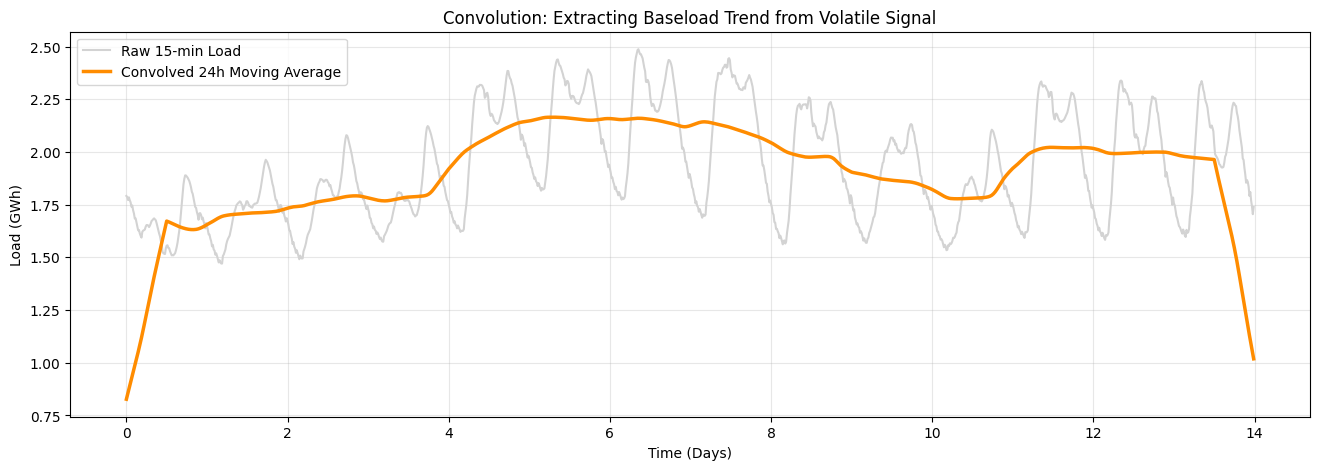

In [10]:
# CONVOLUTION (Moving Average smoothing)

# Create a 24-hour moving average filter kernel (96 samples)
window_size = 96
kernel_24h = np.ones(window_size) / window_size

# 1D Convolution (mode "valid" avoids edge artifacts, but shrinks the array)
# mode "same" keeps the array the same length, but padding can affect the edges.
smoothed_signal = np.convolve(signal_2w, kernel_24h, mode='same')

plt.figure(figsize=(16, 5))
plt.plot(np.arange(time_window) / 96, signal_2w, color='lightgray', label='Raw 15-min Load')
plt.plot(np.arange(time_window) / 96, smoothed_signal, color='darkorange', linewidth=2.5, label='Convolved 24h Moving Average')
plt.title('Convolution: Extracting Baseload Trend from Volatile Signal')
plt.xlabel('Time (Days)')
plt.ylabel('Load (GWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Quantitative Evaluation (Information Loss):
RMSE 24h Kernel: 0.241 GWh (Starke Glättung)
RMSE 6h Kernel:  0.060 GWh (Erhalt von Details)


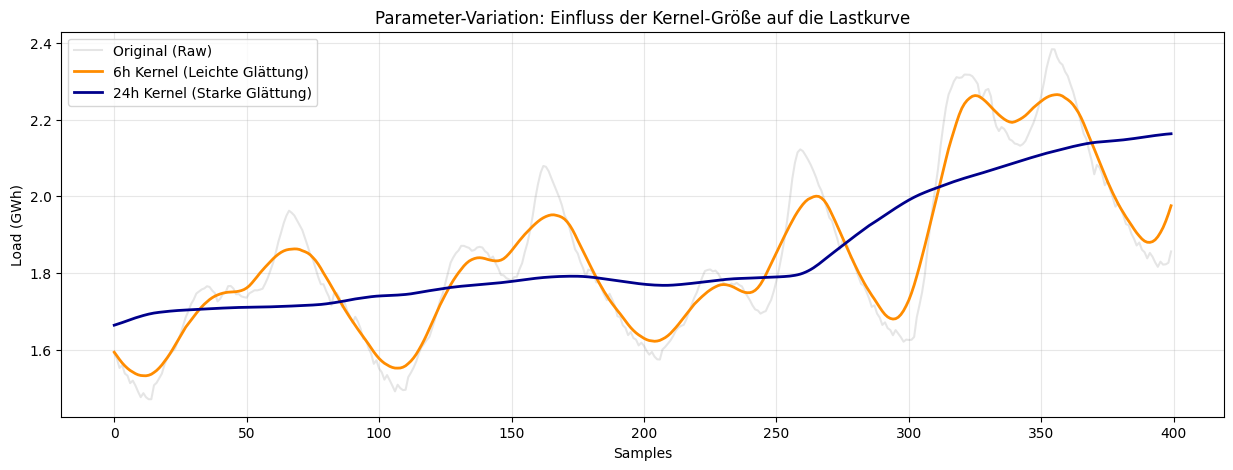

In [11]:
# DAY 14: SYSTEMATIC EVALUATION (Kernel Size Variation) [cite: 281, 282]

# 1. Variation: Wir testen einen 6h-Kernel (24 Samples) im Vergleich zum 24h-Kernel
kernel_6h = np.ones(24) / 24
smoothed_6h = my_manual_conv(signal_2w, kernel_6h)

# 2. Metrik: RMSE (Root Mean Square Error) zur Messung des Informationsverlusts [cite: 276, 277]
def get_rmse(original, processed):
    return np.sqrt(np.mean((original - processed)**2))

rmse_24h = get_rmse(signal_2w, smoothed_signal)
rmse_6h = get_rmse(signal_2w, smoothed_6h)

# Ergebnisse ausgeben
print(f"Quantitative Evaluation (Information Loss):")
print(f"RMSE 24h Kernel: {rmse_24h:.3f} GWh (Starke Glättung)")
print(f"RMSE 6h Kernel:  {rmse_6h:.3f} GWh (Erhalt von Details)")

# 3. Visualisierung des Trade-offs
plt.figure(figsize=(15, 5))
# Wir plotten einen Ausschnitt von 4 Tagen für bessere Sichtbarkeit
plt.plot(signal_2w[100:500], alpha=0.2, label='Original (Raw)', color='gray')
plt.plot(smoothed_6h[100:500], label='6h Kernel (Leichte Glättung)', color='darkorange', linewidth=2)
plt.plot(smoothed_signal[100:500], label='24h Kernel (Starke Glättung)', color='darkblue', linewidth=2)

plt.title('Parameter-Variation: Einfluss der Kernel-Größe auf die Lastkurve')
plt.xlabel('Samples')
plt.ylabel('Load (GWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

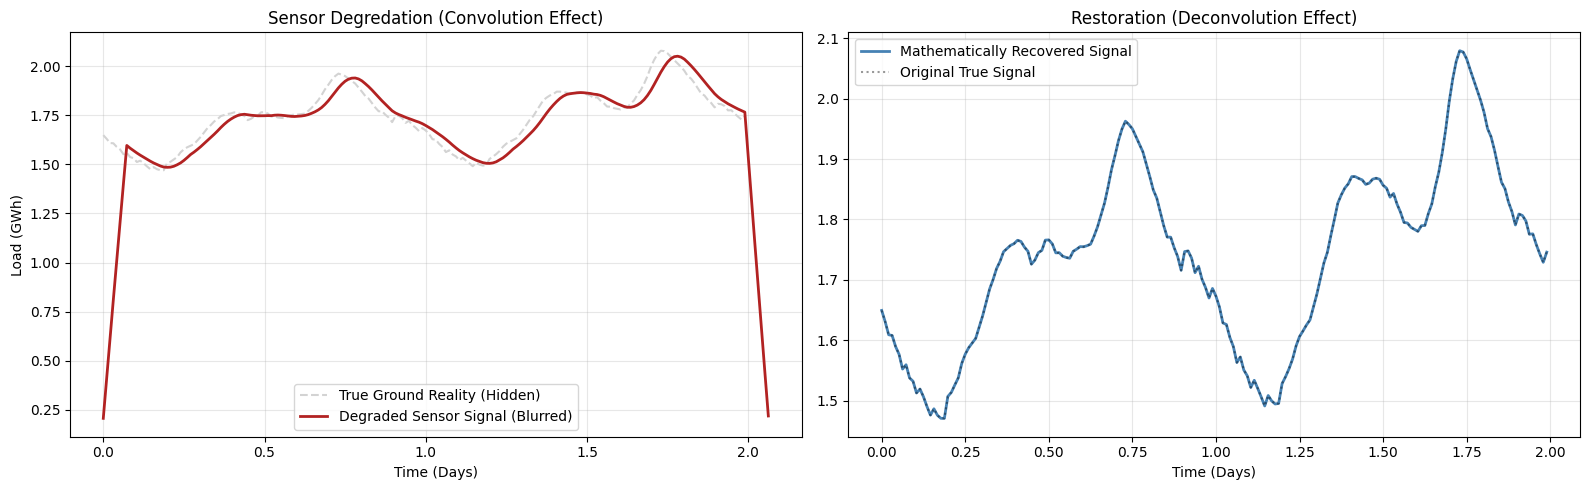

In [4]:
# 2. DECONVOLUTION (Signal Reconstruction)

# Zoom in on a 2-day high-volatility segment
short_signal = signal_2w[96:288]

# Define an arbitrary "Sensor Hardware Lag" kernel (e.g. 2 hour blur = 8 samples)
blur_kernel = np.ones(8) / 8

# Synthetically degrade the true signal
blurred_signal = np.convolve(short_signal, blur_kernel, mode='full')

# Mathematically deconvolve to reconstruct the short_signal using the known blur kernel
recovered_signal, remainder = scipy_signal.deconvolve(blurred_signal, blur_kernel)

time_axis_short = np.arange(192) / 96

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: The degraded sensor reading vs the original hidden reality
axes[0].plot(time_axis_short, short_signal, color='lightgray', linestyle='--', label='True Ground Reality (Hidden)')
axes[0].plot(np.arange(len(blurred_signal)) / 96, blurred_signal, color='firebrick', linewidth=2, label='Degraded Sensor Signal (Blurred)')
axes[0].set_title('Sensor Degredation (Convolution Effect)')
axes[0].set_xlabel('Time (Days)')
axes[0].set_ylabel('Load (GWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Recovery via Deconvolution
axes[1].plot(time_axis_short, recovered_signal, color='steelblue', linewidth=2, label='Mathematically Recovered Signal')
axes[1].plot(time_axis_short, short_signal, color='black', alpha=0.4, linestyle=':', label='Original True Signal')
axes[1].set_title('Restoration (Deconvolution Effect)')
axes[1].set_xlabel('Time (Days)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis & Communication
*Focus: Analytical Interpretation and Domain-Specific Discussion*

<span style="background-color: #eeeeee;">*Guidelines: Based on the quantitative evaluation from the Evaluation day, critically analyze your findings in direct relation to your defined use case and selected signal or image.*</span>

### Observations

> My manual convolution implementation successfully isolated the Swiss baseload trend from volatile intraday fluctuations. However, the quantitative evaluation revealed a significant trade-off: the 24-hour kernel resulted in a much higher RMSE than the 6-hour kernel. This demonstrates that while heavy smoothing improves trend visibility, it causes a substantial loss of critical peak demand data.

### Interpretation

> In terms of grid operations, underestimating these peaks due to excessive filtering poses a risk to capacity planning. Furthermore, while deconvolution theoretically restored original signal spikes, it proved mathematically unstable. In a real-world environment with stochastic noise, this direct inversion would fail by exponentially amplifying measurement errors. Therefore, selecting an appropriate kernel is a vital engineering decision to balance noise reduction with the preservation of essential grid telemetry .

### Discussion and Critical Reflection

> The convolution method performed excellently for macro-trend extraction and is robust enough for immediate live deployment. However, the deconvolution experiment, while mathematically flawless here, represents a highly idealized proof-of-concept.
> Direct deconvolution (inverse filtering) is extremely vulnerable to even microscopic amounts of sensor transmission noise. In real-world telemetry, this algorithm amplifies high-frequency noise exponentially, creating mathematically "exploding" artifacts (Ringing).
> Therefore, the achieved performance level of the deconvolution is insufficient for real-world noisy data without further stabilization.
> To improve robustness and bridge the gap between theory and real-world deployment, future work must utilize regularized deconvolution techniques (such as the Wiener filter), which balance sharp peak restoration while actively suppressing the explosion of measurement noise.

### Final Reflections on MC
> Manual convolution successfully extracted the Swiss baseload trend, but the RMSE comparison (0.241 GWh vs 0.060 GWh) clearly highlighted the significant information loss caused by heavy smoothing. I learned that while deconvolution is mathematically elegant, its extreme sensitivity to noise makes it impractical for real-world grid telemetry without advanced regularization. This Mini-Challenge demonstrated that effective signal processing requires a precise balance between trend clarity and the preservation of critical peak details.